In [1]:
import numpy as np
import matplotlib.pyplot as plt
import linecache

Msolar = 1.989000e+33
G = 6.67408e-08
AU = 1.495979e+13
kB = 1.38064852e-16
mH = 1.67353e-24
mu = 2.34
yr = 3.155760e+07

In [6]:
filename = "test_resistivity.txt"
species = species = linecache.getline(filename, 1)
species = species.split()[3:-3]
data = np.loadtxt(filename, float, skiprows=1).T
ng = data[0]
T = data[1]
B = data[2]
number_of_species = len(species)
print(number_of_species)
abunds = data[3:number_of_species+3]
etaO = data[number_of_species+3]
etaH = data[number_of_species+4]
etaA = data[number_of_species+5]
linecache.clearcache()
print(species)

min_charge = -1
max_charge = 1
num_charge = max_charge - min_charge + 1
dust_abund_charge_total = np.zeros((num_charge, len(ng)), float)
for i in range(number_of_species):
    if (species[i][0:2] == "Ds"):
        position_c = species[i].find("c")
        charge = int(species[i][position_c+1:])
        index = charge
        # print(species[i], charge, index)
        dust_abund_charge_total[index] += abunds[i]

27
['H', 'C', 'Mg', 'O', 'He', 'OH', 'CO', 'O2', 'H2', 'H2O', 'HCO', 'C+', 'He+', 'H+', 'Mg+', 'O+', 'e-', 'H2+', 'OH+', 'O2+', 'H3+', 'HCO+', 'H2O+', 'H3O+', 'Ds1c-1', 'Ds1c+0', 'Ds1c+1']


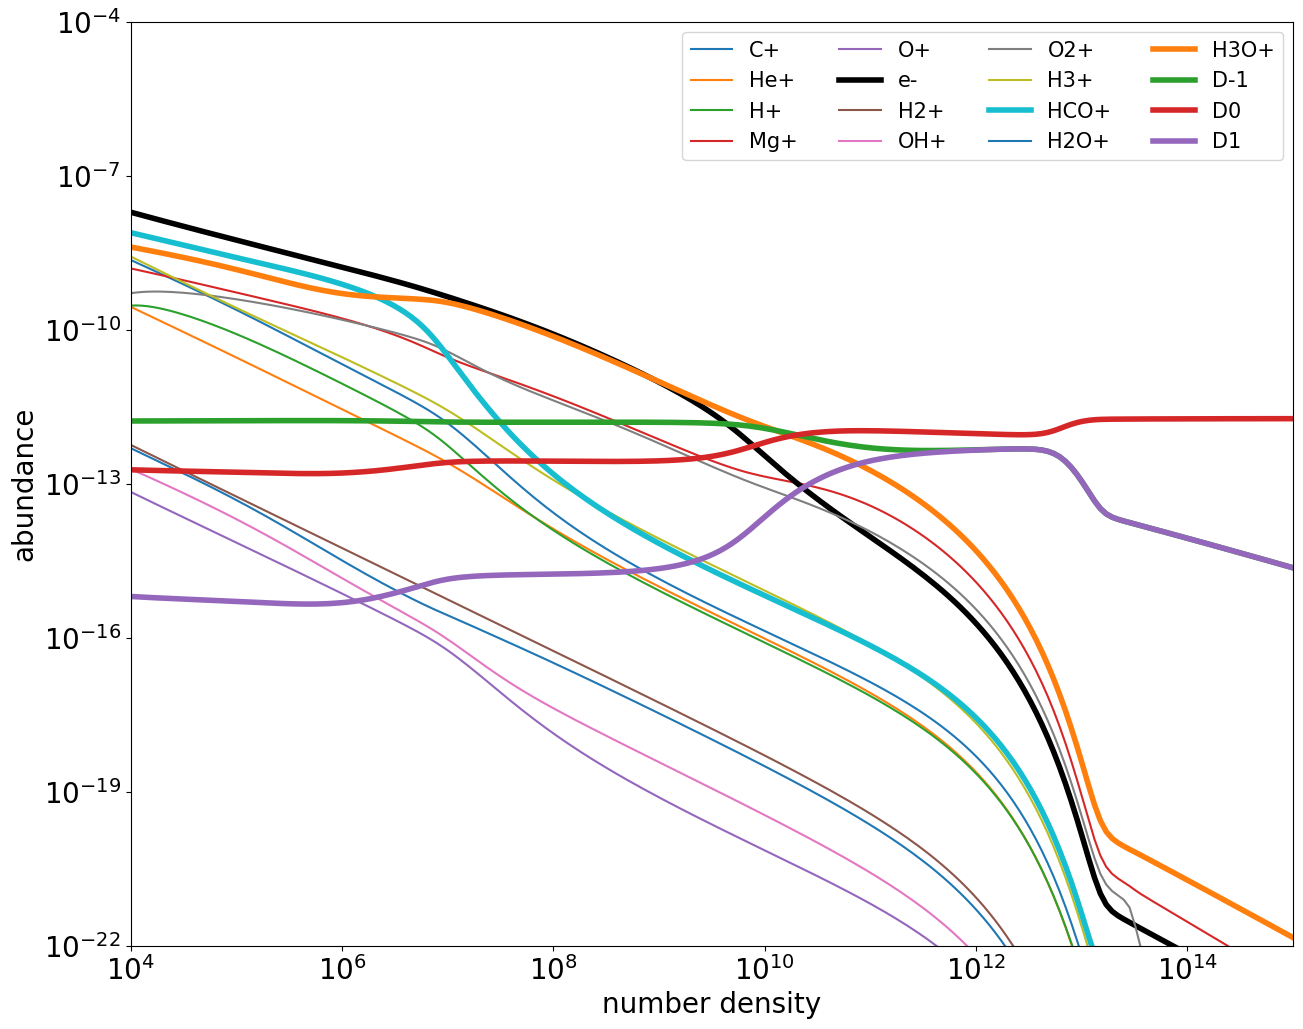

In [7]:
plt.figure(figsize=(15, 12))
for i in range(number_of_species):
    if (species[i] == "e-"):
        plt.plot(ng, abunds[i], label=species[i], lw=4, color="black")
    elif (species[i] == "HCO+"):
        plt.plot(ng, abunds[i], label=species[i], lw=4)
    elif (species[i] == "H3O+"):
        plt.plot(ng, abunds[i], label=species[i], lw=4)
    elif (species[i][-1] == "+" or species[i][-1] == "-"):
        plt.plot(ng, abunds[i], label=species[i])
    else:
        pass
for i in range(min_charge, max_charge+1):
    label_ch = "D" + str(i)
    plt.plot(ng, dust_abund_charge_total[i], lw=4, label=label_ch)
plt.xscale("log")
plt.yscale("log")
plt.xlim(ng[0], ng[-1])
plt.ylim(1.0e-22, 1.0e-4)
plt.xlabel("number density", fontsize=20)
plt.ylabel("abundance", fontsize=20)
plt.tick_params(labelsize=20)
# plt.legend(fontsize=15, loc='upper center', bbox_to_anchor=(.5, -.15), ncol=5)
plt.legend(fontsize=15, loc='upper right', ncol=4)
plt.show()

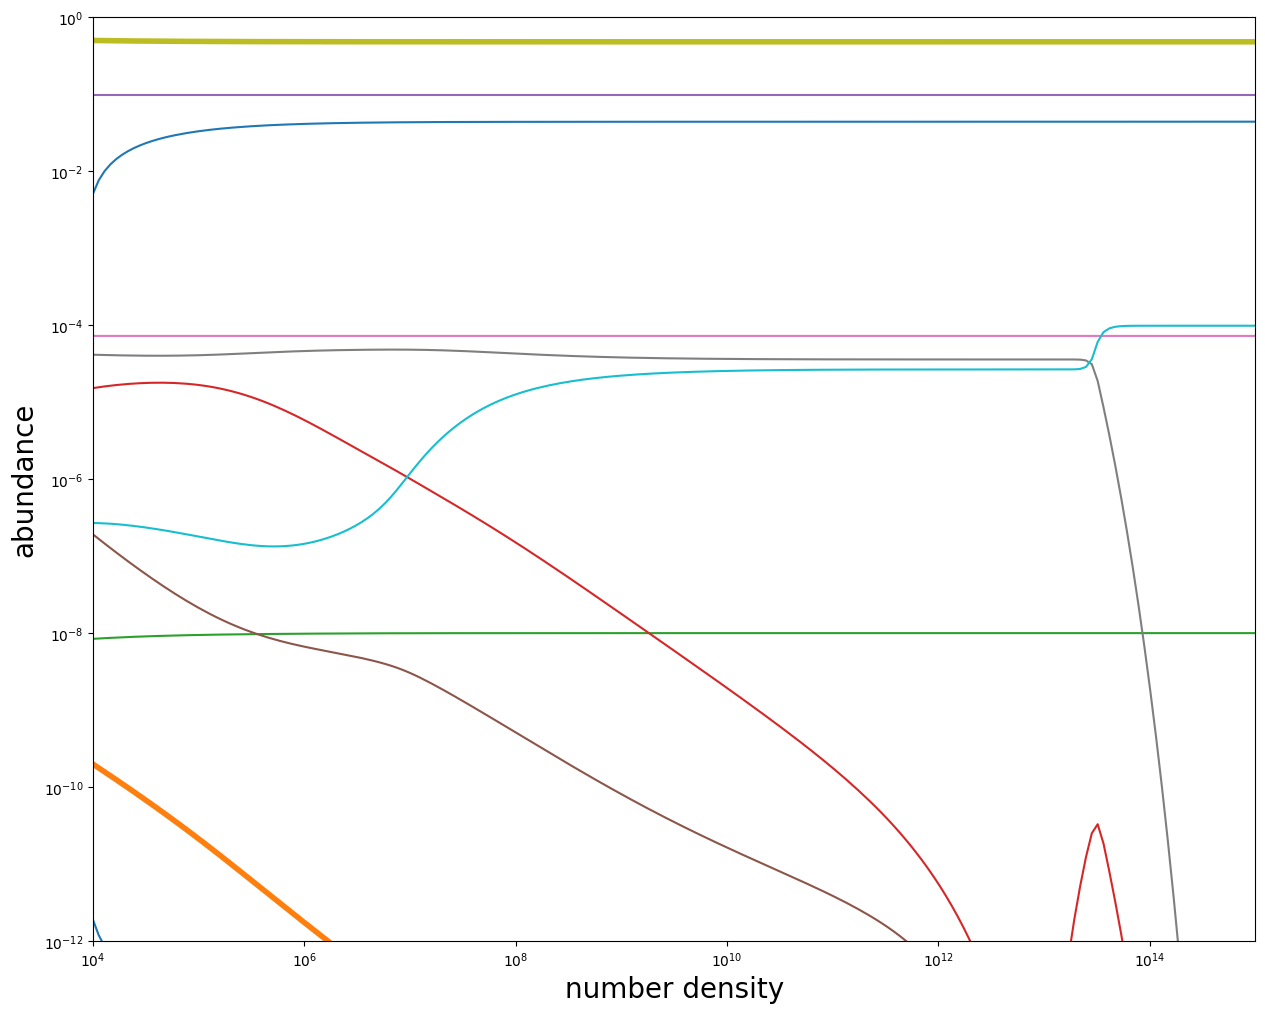

In [8]:
plt.figure(figsize=(15, 12))
for i in range(number_of_species):
    if (species[i][-1] == "+" or species[i][-1] == "-" or species[i][0] == "D"):
        pass
    elif (species[i] == "C" or species[i] =="H2"):
        plt.plot(ng, abunds[i], label=species[i], lw=4)
    else:
        plt.plot(ng, abunds[i], label=species[i])
plt.xscale("log")
plt.yscale("log")
plt.xlim(ng[0], ng[-1])
plt.ylim(1.0e-12, 1.0)
plt.xlabel("number density", fontsize=20)
plt.ylabel("abundance", fontsize=20)
# plt.legend(fontsize=15, loc='upper center', bbox_to_anchor=(.5, -.15), ncol=5)
# plt.legend(fontsize=15, loc='lower left', ncol=4)
plt.show()

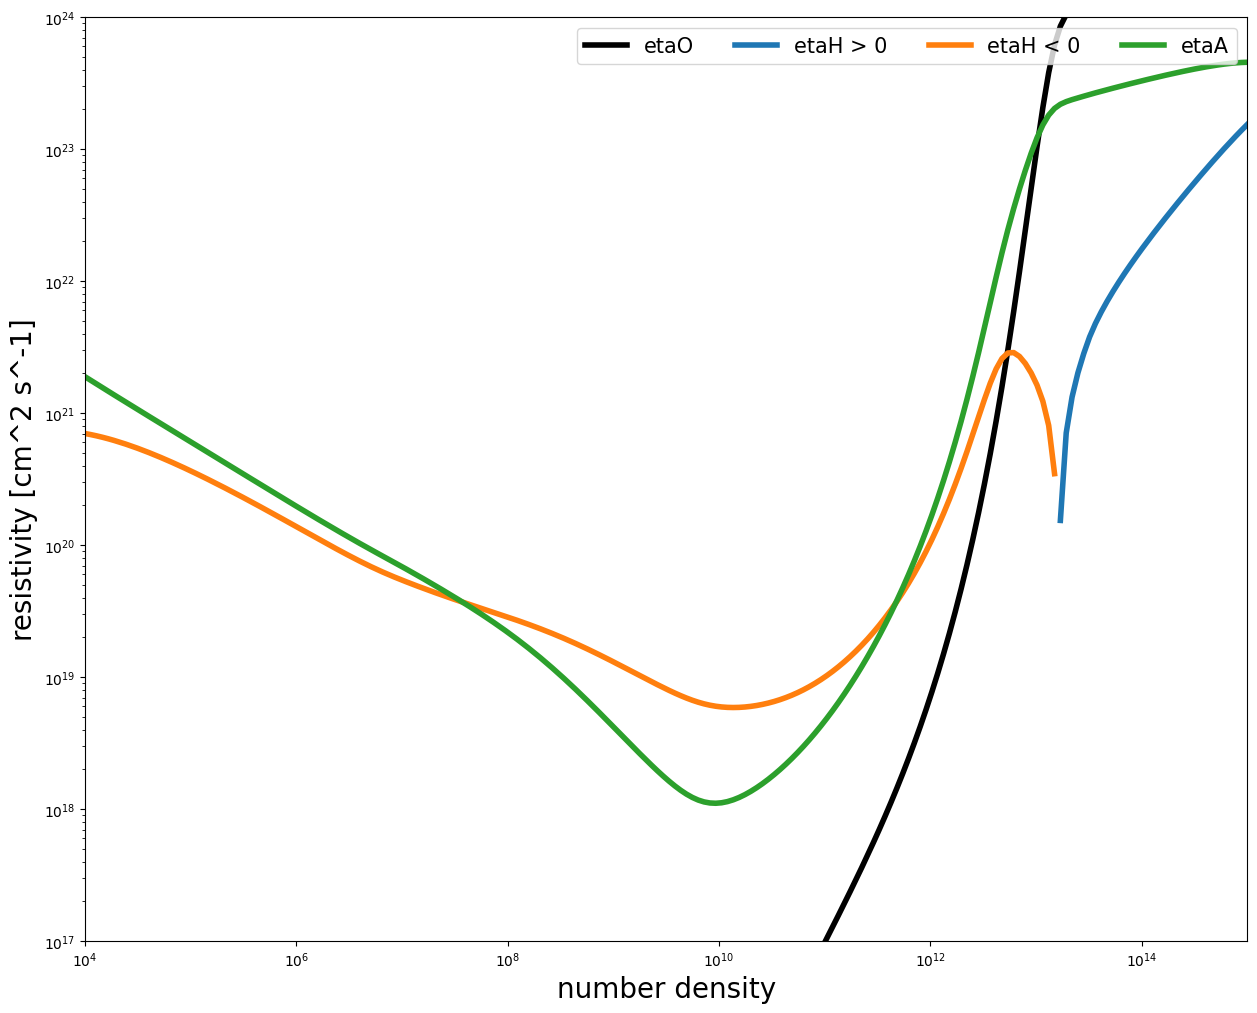

In [9]:
plt.figure(figsize=(15, 12))
plt.plot(ng, etaO, lw = 4, label="etaO", color="black")
plt.plot(ng, np.abs(np.where(etaH > 0.0, etaH, np.nan)), lw = 4, label="etaH > 0")
plt.plot(ng, np.abs(np.where(etaH < 0.0, etaH, np.nan)), lw = 4, label="etaH < 0")
plt.plot(ng, etaA, lw = 4, label="etaA")
plt.xscale("log")
plt.yscale("log")
plt.xlim(ng[0], ng[-1])
plt.ylim(1.0e17, 1.0e24)
plt.xlabel("number density", fontsize=20)
plt.ylabel("resistivity [cm^2 s^-1]", fontsize=20)
plt.legend(fontsize=15, loc='upper right', ncol=4)
plt.show()